# Satellite Land Cover Classification
## 04 - Model Analysis and Optimization

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
# Load the processed dataset
data_path = Path("../data/processed/satellite_landcover_features.csv")

df = pd.read_csv(data_path)

df.head()

,Mean_R,Mean_G,Mean_B,Std_R,Std_G,Std_B,Label,Brightness
0,44.347412,64.375488,80.707031,3.513459,3.138506,2.012561,Forest,63.143311
1,46.671143,73.987549,83.954102,6.793193,5.550029,4.262200,Forest,68.204264
2,32.073975,55.816162,67.113281,4.821334,5.024223,2.951324,Forest,51.667806
3,41.936279,65.127930,81.393555,1.940922,1.913598,1.871846,Forest,62.819255
4,39.153076,63.942383,77.635010,2.308962,2.951115,1.872090,Forest,60.243490


In [4]:
df["Label"].value_counts()

Label
Forest         3000
Residential    3000
River          2500
Name: count, dtype: int64

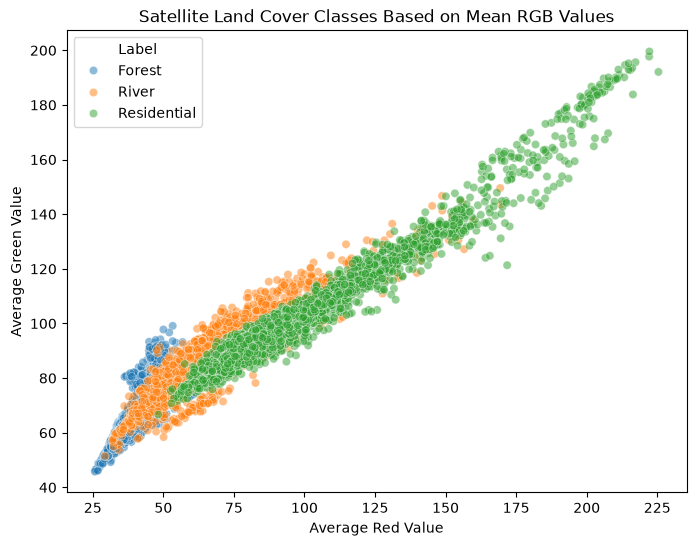

In [5]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Mean_R",
    y="Mean_G",
    hue="Label",
    alpha=0.5
)

plt.title("Satellite Land Cover Classes Based on Mean RGB Values")
plt.xlabel("Average Red Value")
plt.ylabel("Average Green Value")

plt.show()

In [6]:
df.groupby("Label")[["Mean_R", "Mean_G", "Mean_B", "Brightness"]].mean()

,Mean_R,Mean_G,Mean_B,Brightness
Label,,,,
Forest,39.359913,64.455616,75.960975,59.925501
Residential,100.058339,103.786874,113.017563,105.620925
River,67.035443,86.616585,96.897334,83.516454


In [7]:
# Prepare training and testing data again

X = df.drop("Label", axis=1)
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

k_values = [1, 3, 5, 7, 9, 11]

accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

accuracies

[0.9570588235294117,
 0.9652941176470589,
 0.9676470588235294,
 0.9582352941176471,
 0.9541176470588235,
 0.9552941176470588]

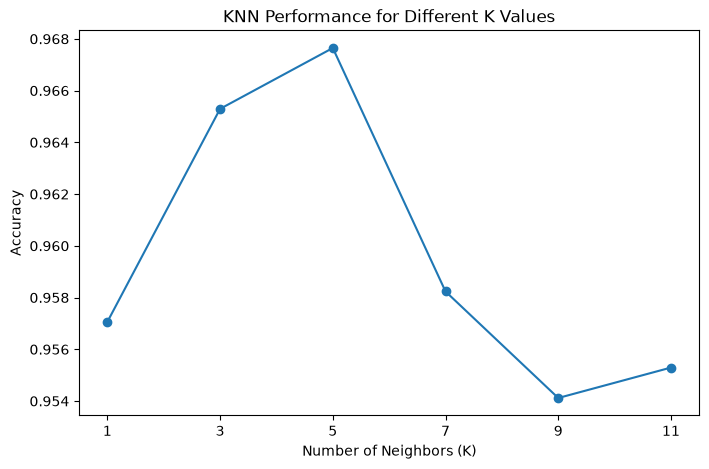

In [9]:
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Performance for Different K Values")

plt.xticks(k_values)

plt.show()

In [10]:
results = pd.DataFrame({
    "K Value": k_values,
    "Accuracy": accuracies
})

results

,K Value,Accuracy
0,1,0.957059
1,3,0.965294
2,5,0.967647
3,7,0.958235
4,9,0.954118
5,11,0.955294


In [11]:
results["Accuracy (%)"] = results["Accuracy"] * 100

results

,K Value,Accuracy,Accuracy (%)
0,1,0.957059,95.705882
1,3,0.965294,96.529412
2,5,0.967647,96.764706
3,7,0.958235,95.823529
4,9,0.954118,95.411765
5,11,0.955294,95.529412


In [12]:
best_result = results.loc[results["Accuracy"].idxmax()]

best_result

K Value          5.000000
Accuracy         0.967647
Accuracy (%)    96.764706
Name: 2, dtype: float64

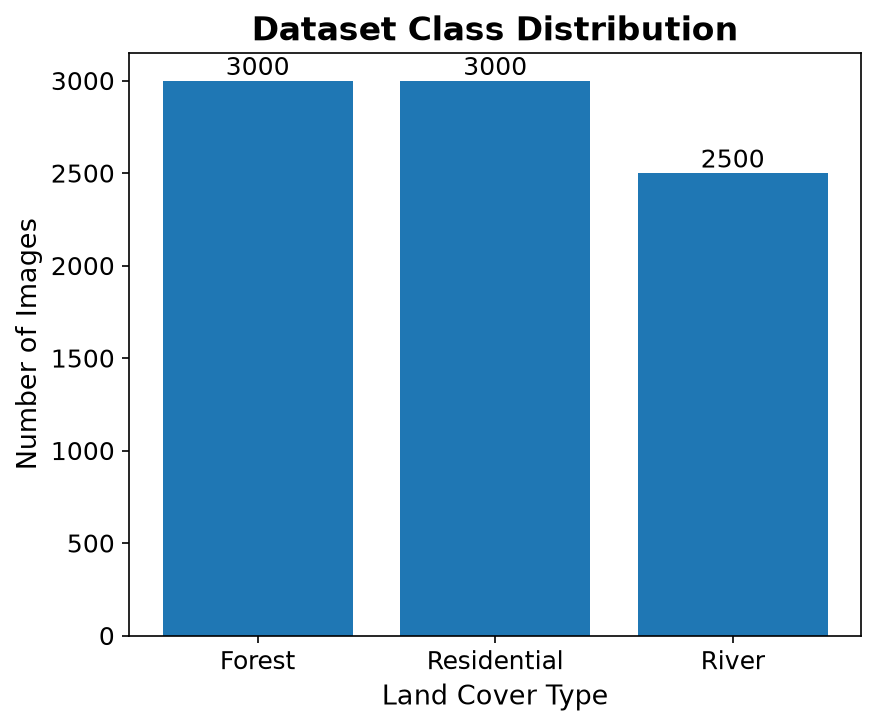

In [14]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["figure.dpi"] = 150
counts = df["Label"].value_counts()

plt.figure(figsize=(6,5))

bars = plt.bar(
    counts.index,
    counts.values
)

plt.title("Dataset Class Distribution",
          fontweight="bold")

plt.xlabel("Land Cover Type")
plt.ylabel("Number of Images")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+30,
        int(bar.get_height()),
        ha="center"
    )

plt.tight_layout()

plt.savefig("../images/class_distribution.png",
            dpi=300)

plt.show()

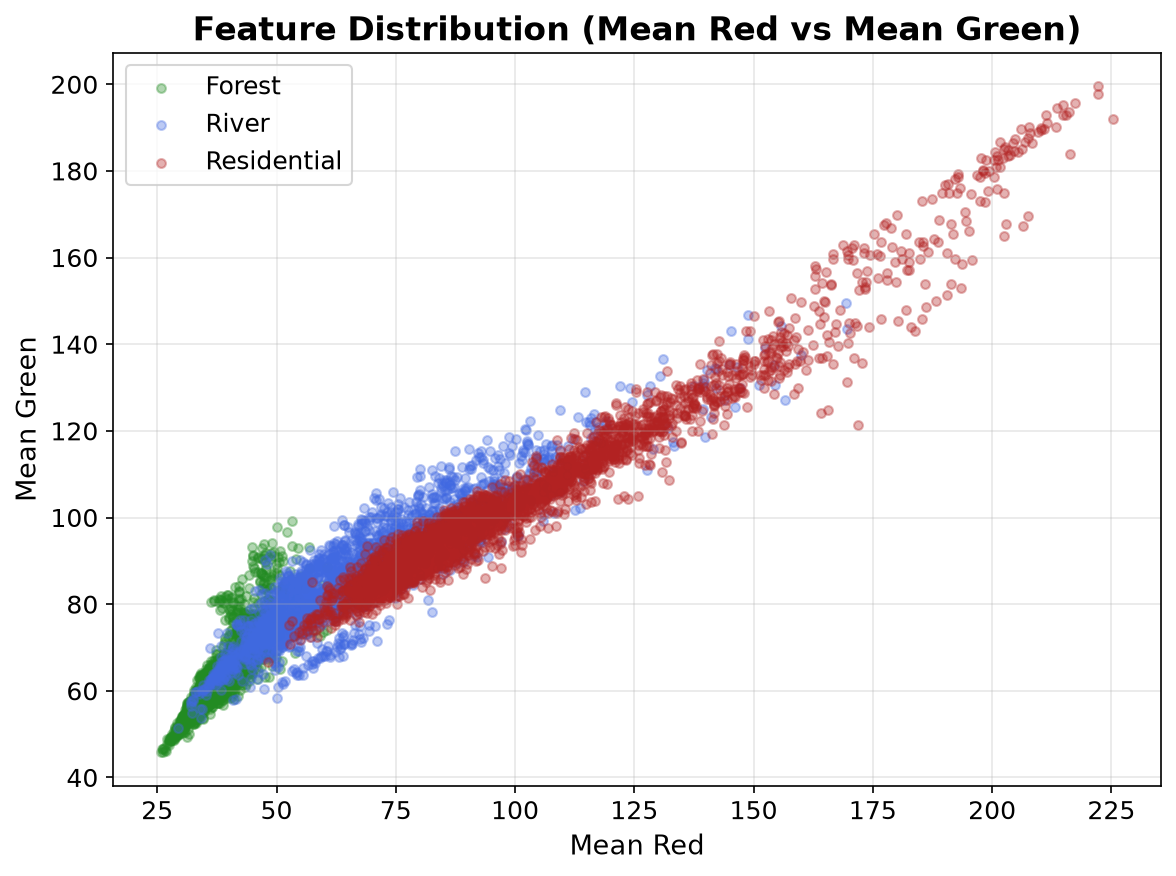

In [15]:
colors = {
    "Forest":"forestgreen",
    "River":"royalblue",
    "Residential":"firebrick"
}

plt.figure(figsize=(8,6))

for label,color in colors.items():

    subset = df[df["Label"]==label]

    plt.scatter(
        subset["Mean_R"],
        subset["Mean_G"],
        alpha=0.35,
        s=18,
        label=label,
        color=color
    )

plt.title("Feature Distribution (Mean Red vs Mean Green)",
          fontweight="bold")

plt.xlabel("Mean Red")
plt.ylabel("Mean Green")

plt.legend()

plt.grid(alpha=.3)

plt.tight_layout()

plt.savefig("../images/feature_distribution.png",
            dpi=300)

plt.show()

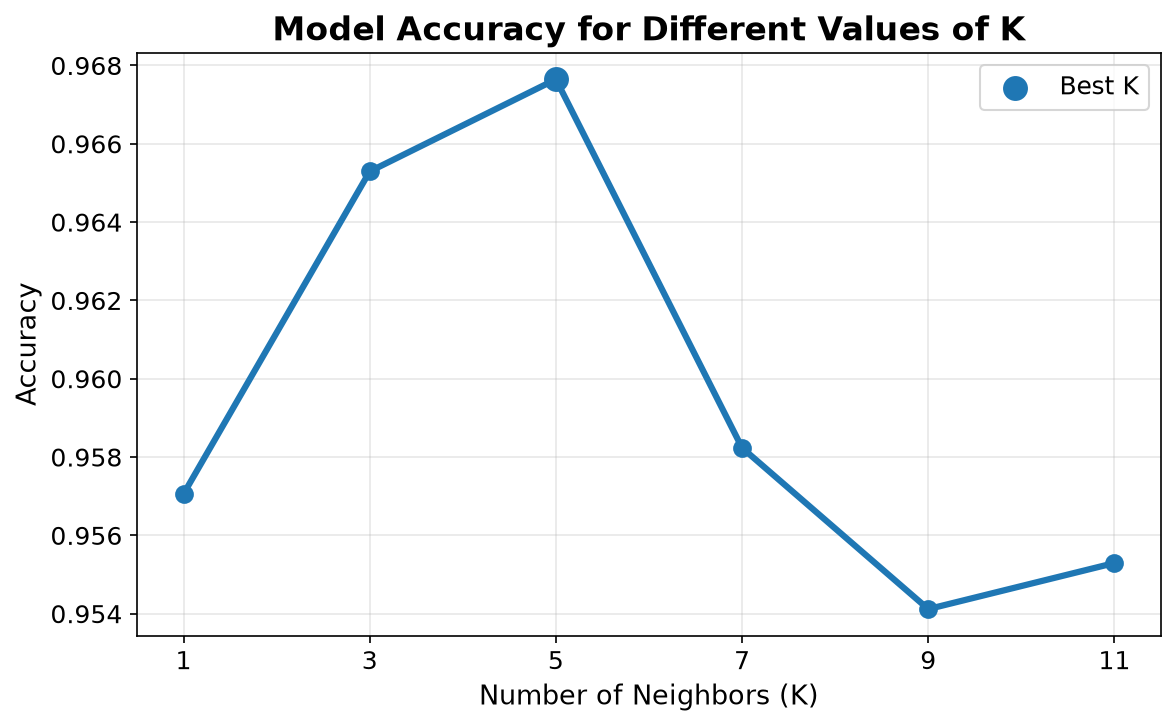

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    accuracies,
    marker="o",
    linewidth=3,
    markersize=8
)

best_index = accuracies.index(max(accuracies))

plt.scatter(
    k_values[best_index],
    accuracies[best_index],
    s=120,
    zorder=5,
    label="Best K"
)

plt.title("Model Accuracy for Different Values of K",
          fontweight="bold")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.xticks(k_values)

plt.grid(alpha=.3)

plt.legend()

plt.tight_layout()

plt.savefig("../images/k_value_accuracy.png",
            dpi=300)

plt.show()